## Airbnb Data Analysis: Pricing Strategy and Demand Optimization

### Objective:<br>
The goal is to analyze Airbnb listings data to identify key factors affecting pricing, demand behavior and availability.

In [1]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sea

In [18]:
#loading the dataset
air1=pd.read_csv('AB_NYC_2019.csv')

## Overview of Dataset:
Dataset Description

The dataset contains Airbnb listings with features such as:
- Price
- Room Type
- Location (Neighbourhood)
- Availability
- Number of Reviews

Key Questions:
- Which locations have the highest prices?
- What type of properties generate more revenue?
- How does availability relate to demand?

In [3]:
#Original Dataset
air1

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,19-10-2018,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,21-05-2019,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,05-07-2019,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,19-11-2018,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [4]:
air1.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

# Data Preprocessing

In [5]:
#Selecting only the necessary columns for the analysis
air=air1[['name','host_id','host_name','neighbourhood_group','room_type','price','number_of_reviews',
          'minimum_nights','reviews_per_month','availability_365']]
air.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 48879 non-null  str    
 1   host_id              48895 non-null  int64  
 2   host_name            48874 non-null  str    
 3   neighbourhood_group  48895 non-null  str    
 4   room_type            48895 non-null  str    
 5   price                48895 non-null  int64  
 6   number_of_reviews    48895 non-null  int64  
 7   minimum_nights       48895 non-null  int64  
 8   reviews_per_month    38843 non-null  float64
 9   availability_365     48895 non-null  int64  
dtypes: float64(1), int64(5), str(4)
memory usage: 3.7 MB


In [6]:
air.describe()

,host_id,price,number_of_reviews,minimum_nights,reviews_per_month,availability_365
count,4.889500e+04,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000
mean,6.762001e+07,152.720687,23.274466,7.029962,1.373221,112.781327
std,7.861097e+07,240.154170,44.550582,20.510550,1.680442,131.622289
min,2.438000e+03,0.000000,0.000000,1.000000,0.010000,0.000000
25%,7.822033e+06,69.000000,1.000000,1.000000,0.190000,0.000000
50%,3.079382e+07,106.000000,5.000000,3.000000,0.720000,45.000000
75%,1.074344e+08,175.000000,24.000000,5.000000,2.020000,227.000000
max,2.743213e+08,10000.000000,629.000000,1250.000000,58.500000,365.000000


In [7]:
#Data Cleaning
#Step 1:check for null values and duplicate values
print("The Null Values are:\n",air.isnull().sum())
print("\nThe Duplicate Values are:",air.duplicated().sum())

The Null Values are:
 name                      16
host_id                    0
host_name                 21
neighbourhood_group        0
room_type                  0
price                      0
number_of_reviews          0
minimum_nights             0
reviews_per_month      10052
availability_365           0
dtype: int64

The Duplicate Values are: 22


In [8]:
#Step 2:Handling the null values and duplicate values
#Dropping Duplicate Values
air.drop_duplicates(inplace=True)
#Filling the null values in 'reviews_per_month' column with 0
#Reason:Missing values in reviews_per_month were replaced with 0 as they represent listings with no reviews.
air.fillna({'reviews_per_month': 0}, inplace=True)

,name,host_id,host_name,neighbourhood_group,room_type,price,number_of_reviews,minimum_nights,reviews_per_month,availability_365
0,Clean & quiet apt home by the park,2787,John,Brooklyn,Private room,149,9,1,0.21,365
1,Skylit Midtown Castle,2845,Jennifer,Manhattan,Entire home/apt,225,45,1,0.38,355
2,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Private room,150,0,3,0.00,365
3,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Entire home/apt,89,270,1,4.64,194
4,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,Entire home/apt,80,9,10,0.10,0
...,...,...,...,...,...,...,...,...,...,...
48890,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Private room,70,0,2,0.00,9
48891,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Private room,40,0,4,0.00,36
48892,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Entire home/apt,115,0,10,0.00,27
48893,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Shared room,55,0,1,0.00,2


In [9]:
#Dropping columns which have missing values and are not useful for the analysis
air.drop(columns=['name','host_name'], inplace=True)

## Data Cleaning

Steps performed:
- Removed missing/null values
- Dropped irrelevant columns
- Checked duplicates
- Converted data types where required

This ensures the dataset is accurate and ready for analysis.

In [10]:
air.info()

<class 'pandas.DataFrame'>
Index: 48873 entries, 0 to 48894
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   host_id              48873 non-null  int64  
 1   neighbourhood_group  48873 non-null  str    
 2   room_type            48873 non-null  str    
 3   price                48873 non-null  int64  
 4   number_of_reviews    48873 non-null  int64  
 5   minimum_nights       48873 non-null  int64  
 6   reviews_per_month    48873 non-null  float64
 7   availability_365     48873 non-null  int64  
dtypes: float64(1), int64(5), str(2)
memory usage: 3.4 MB


In [11]:
air.isnull().sum()

host_id                0
neighbourhood_group    0
room_type              0
price                  0
number_of_reviews      0
minimum_nights         0
reviews_per_month      0
availability_365       0
dtype: int64

# Exploratory Data Analysis

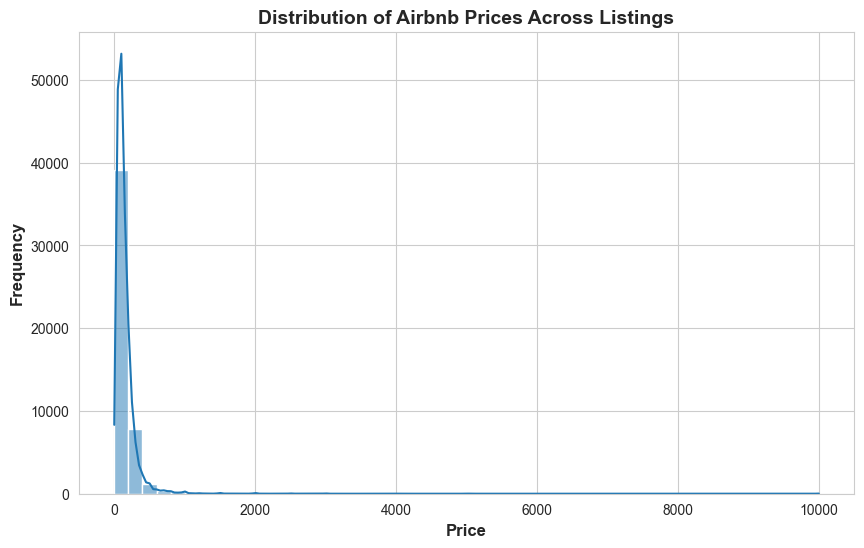

<Figure size 640x480 with 0 Axes>

In [19]:
#Overall Price Distribution
plt.figure(figsize=(10,6))
sea.histplot(air['price'], bins=50, kde=True)
plt.title('Distribution of Airbnb Prices Across Listings', fontsize=14, fontweight='bold')
plt.xlabel('Price', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.show()
plt.savefig('Overall_Price_Distribution.png')

# Interpretation:
- Most Airbnb listings fall in the low to mid-price range
- The distribution is right-skewed, with few very high-priced listings
- These high-priced listings act as outliers
- This indicates that majority of customers prefer affordable options
- Premium listings exist but cater to a smaller niche segment

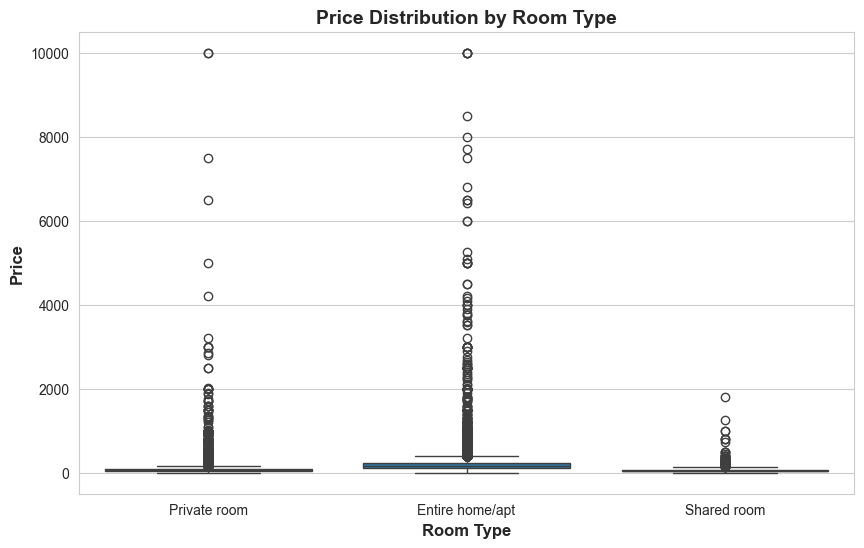

<Figure size 640x480 with 0 Axes>

In [23]:
#Price Distribution by Room type
plt.figure(figsize=(10,6))
sea.set_style('whitegrid')
sea.boxplot(x='room_type',y='price', data=air)
plt.title('Price Distribution by Room Type', fontweight='bold',fontsize=14)
plt.xlabel('Room Type', fontweight='bold', fontsize=12)
plt.ylabel('Price', fontweight='bold', fontsize=12)
plt.show()
plt.savefig('Price_Distribution_by_Room_Type.png')

# Interpretation:
- Entire home/apartment listings have the highest average price
- This is due to privacy, exclusive feature and full property access
- Private rooms are moderately priced, balancing cost and comfort
- Shared rooms are the most affordable, targeting budget travelers
- Room type significantly influences pricing due to different customer needs

C:\Users\haral\AppData\Local\Temp\ipykernel_20140\1541655507.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.barplot(x='neighbourhood_group',y='price', data=air,palette='Set2')


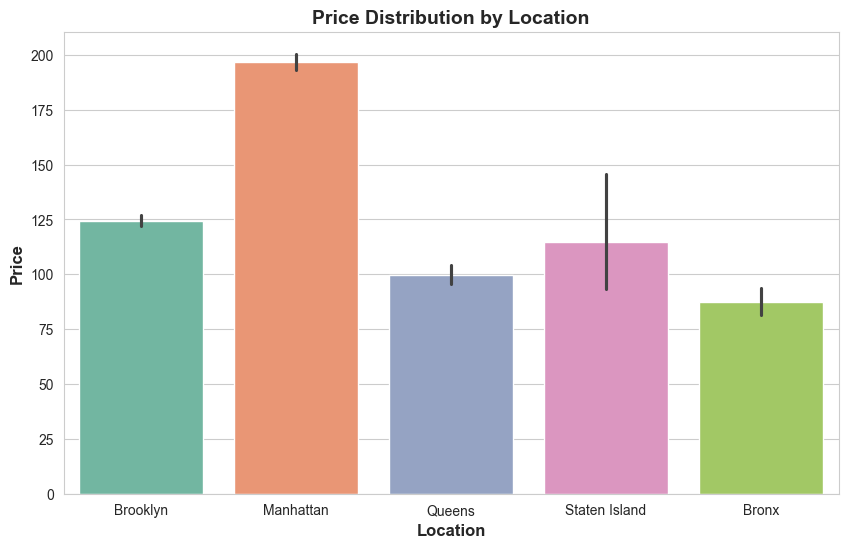

<Figure size 640x480 with 0 Axes>

In [14]:
#Price Distribution by Location
plt.figure(figsize=(10,6))
sea.set_style('whitegrid')
sea.barplot(x='neighbourhood_group',y='price', data=air,palette='Set2')
plt.title('Price Distribution by Location', fontweight='bold',fontsize=14)
plt.xlabel('Location', fontweight='bold', fontsize=12)
plt.ylabel('Price', fontweight='bold', fontsize=12)
plt.show()
plt.savefig('Price_Distribution_by_Location.png')

The Black lines on the top of these bars represent variation/existence of uncertainty around the average values <br><br>
# Interpretation:
- Manhattan has the highest average prices, showing premium demand
- Brooklyn is the second most expensive area
- Queens and Bronx offer more affordable listings
- Pricing varies strongly based on location attractiveness and accessibility
- Central and popular areas command higher prices due to demand

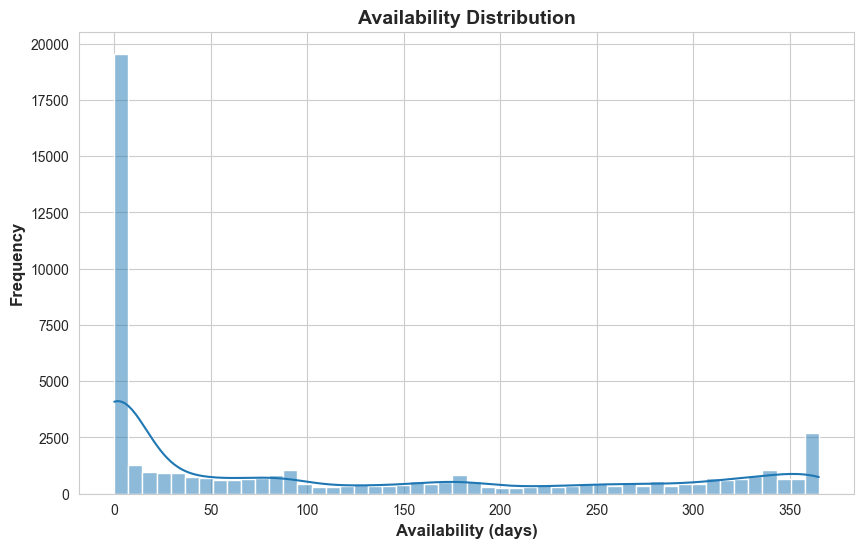

<Figure size 640x480 with 0 Axes>

In [15]:
#Availability Distribution
plt.figure(figsize=(10,6))
sea.histplot(air['availability_365'], bins=50, kde=True)
plt.title('Availability Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Availability (days)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.show()
plt.savefig('Availability_Distribution.png')

# Interpretation:
- Many listings have very low availability, indicating high demand and frequent bookings
- Some listings have high availability (close to 365 days), showing low demand
- This creates a clear divide between high-performing and low-performing listings
- Demand is not evenly distributed across properties

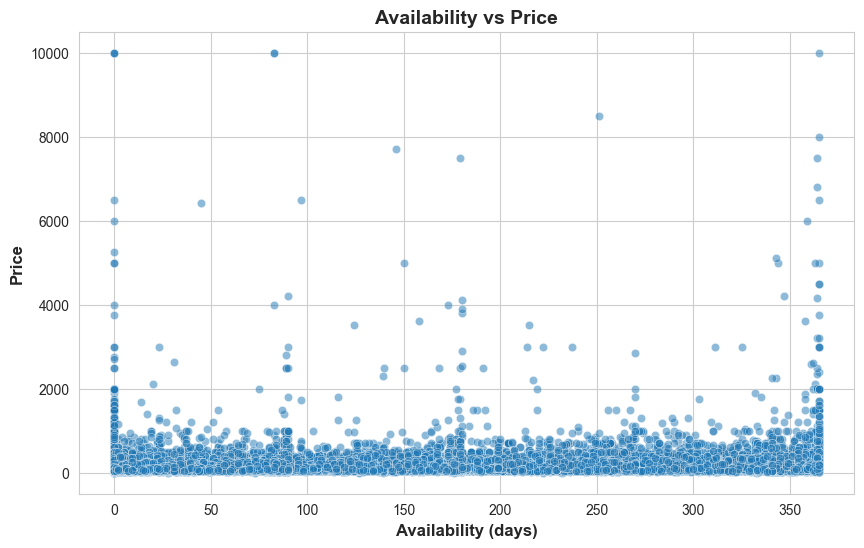

<Figure size 640x480 with 0 Axes>

In [16]:
#Distribution of Availability vs Price
plt.figure(figsize=(10,6))
sea.scatterplot(x='availability_365',y='price', data=air, alpha=0.5)
plt.title('Availability vs Price', fontsize=14, fontweight='bold')
plt.xlabel('Availability (days)', fontsize=12, fontweight='bold')
plt.ylabel('Price', fontsize=12, fontweight='bold')
plt.show()
plt.savefig('Distribution of Availability vs Price.png')

# Interpretation:
- There is no strong relationship between price and availability
- Listings with both high and low availability exist across all price ranges
- Pricing is not directly dependent on demand alone
- Other factors like location, room type, and listing quality play a bigger role

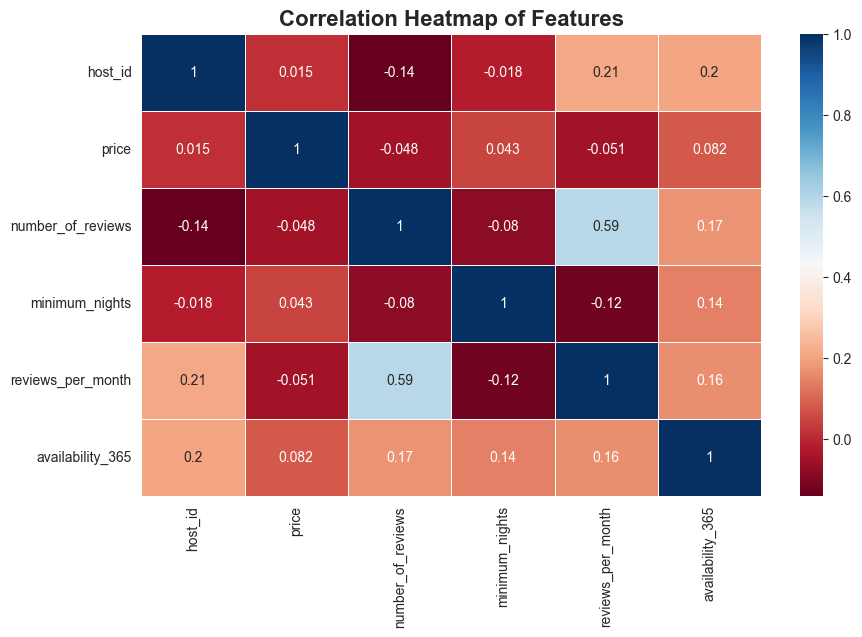

<Figure size 640x480 with 0 Axes>

In [30]:
#Heat Map of Features
corr = air.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sea.heatmap(corr, annot=True, cmap='RdBu', linewidths=0.5)
plt.title("Correlation Heatmap of Features", fontsize=16, fontweight='bold')
plt.show()
plt.savefig('Correlation HeatMap of Features')

Interpretation

The correlation heatmap highlights relationships between key numerical features in the dataset.

1. Price vs Other Variables
- Price shows **weak correlation with most variables**, indicating that pricing is influenced by multiple factors rather than a single feature.
- This suggests that elements like location and room type (categorical variables) play a more significant role in determining price.

2. Number of Reviews vs Reviews per Month
- A **strong positive correlation** is observed between number of reviews and reviews per month.
- This indicates that listings with more reviews tend to receive consistent engagement over time.

3. Availability vs Number of Reviews
- A **negative correlation** is observed between availability and number of reviews.
- This suggests that highly reviewed listings are often booked more frequently, reducing their availability.

4. Minimum Nights vs Price
- A **very weak relationship** exists between minimum nights and price.
- This implies that pricing is not heavily dependent on minimum stay requirements.

5. Overall Insight
- No single numerical variable strongly determines price.
- This confirms that Airbnb pricing is **multi-dimensional**, influenced by both numerical and categorical factors.

In [17]:
#Listing some of the top premium areas 
P_areas=air1.groupby('neighbourhood')['price'].mean().sort_values(ascending=False)
print("These are some of the Top Premium Areas:\n",P_areas.head(10))

These are some of the Top Premium Areas:
 neighbourhood
Fort Wadsworth       800.000000
Woodrow              700.000000
Tribeca              490.638418
Sea Gate             487.857143
Riverdale            442.090909
Prince's Bay         409.500000
Battery Park City    367.557143
Flatiron District    341.925000
Randall Manor        336.000000
NoHo                 295.717949
Name: price, dtype: float64


## Key Business Insights

### 1. Premium Locations Drive Higher Prices
Listings in central areas (like Manhattan) consistently show higher prices, indicating strong demand and willingness to pay.

### 2. Entire Homes Generate Maximum Revenue
Entire home/apartment listings have significantly higher prices compared to private/shared rooms, making them more profitable for hosts.

### 3. Low Availability Indicates High Demand
Listings with fewer available days are often booked more frequently, suggesting higher demand and potential for price optimization.

## Recommendations

- Focus on listing properties in high-demand areas to maximize returns
- Hosts should prioritize entire home listings for better profitability
- Adjust pricing dynamically for properties with high demand (low availability)
- Improve listing visibility and reviews to increase bookings

# Executive Summary

This project analyzed Airbnb listings to understand pricing patterns, demand behavior, and factors influencing revenue.

### Key Takeaways:
- Location plays a critical role in pricing
- Entire homes provide higher earnings
- Demand can be inferred from availability patterns

### Business Impact:
The insights can help hosts make data-driven decisions to increase occupancy and revenue.

## Future Scope
- Build a price prediction model
- Create dashboard for real-time insights
- Use machine learning for demand forecasting